# Adım 11 — Enstrümante varyant (v1.2): zamanlama-MITM'i altıncı sınıf olarak eğitmek

**Neden bu notebook var:** Adım 1–10 boyunca değerlendirilen detektör **pasiftir** — ağı
dışarıdan seyreden bir akış-izleyicinin gördüğü 12 öznitelikle çalışır, hiçbir cihaz işbirliği
yapmaz. Bu pasif katmanın bir körlüğü vardı: paketleri düşürmeden yalnız **geciktiren** bir
zamanlama-MITM, akış-başı transit ölçümünde görünmüyordu (tutma iki akış *arasına* düşüyor;
raporun §7.4'ü). O yüzden `mitm` pasif modele (v1.1) sınıf olarak eklenmedi.

Bu notebook, o körlüğün **ölçüm modalitesini değiştirerek** kaldırıldığı durumu değerlendirir.
Kurban uygulaması her pakete bir gönderim damgası (`SeqTsSizeHeader`) basar, aracı paketi
iletirken bu damgayı **korur**, ve monitörde `Now() − damga` gerçek uçtan-uca gecikmeyi verir.
Bundan üç öznitelik türetilir (`e2e_delay_{median,mean,p95}_ms`) ve pasif 12'nin **üzerine**
eklenir. Bununla `mitm` altıncı bir eğitim sınıfı yapılabiliyor mu, hangi bedelle?

> **İki katmanlı kayıt.** Bu, kanonik pasif detektörü (v1.1) **değiştirmez**. e2e damgası pasif
> değildir (uç cihaz + aracı işbirliği varsayar; gerçek bir MITM başlığı silebilirdi), ve
> göreceğimiz gibi genel macro-F1'i **yükseltmez**. Sonuç ayrı ve açıkça sınırlı bir artefakt
> olarak dondurulur: **enstrümante varyant v1.2**. v1.1 kanonik, pasif headline olarak kalır.

Kaynak: bu değerlendirme daha önce `experiment-packet-tag/mitm_sixclass.py` scriptindeydi;
proje kuralı gereği (notebook serisi) buraya taşındı. Sürüm: `MANIFEST_v1.2.json`,
`detector_v1.2_instrumented.joblib`.

In [1]:
import sys, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Şema tek kaynak (my-work/detector_schema.py). Enstrümante varyant, pasif FEATURES'a 3 e2e
# kolonu ekler: INSTRUMENTED_FEATURES. check_against_release, bu şemanın yayımlanan v1.2
# modelininkiyle birebir (içerik + sıra) aynı olduğunu doğrular; değilse yüksek sesle patlar.
for cand in [Path("..").resolve(), Path("my-work").resolve()]:
    if (cand / "detector_schema.py").exists():
        sys.path.insert(0, str(cand)); break
from detector_schema import FEATURES, INSTRUMENTED_FEATURES, build_X, check_against_release

meta = check_against_release("v1.2")
print("v1.2:", meta["model"]["file"], "| variant:", meta.get("variant"),
      "| canonical:", meta.get("canonical_release"))
print("sınıflar:", meta["model"]["classes"])
print(f"öznitelik: pasif {len(FEATURES)} + e2e 3 = {len(INSTRUMENTED_FEATURES)}")

# Tag'li sweep: aynı senaryolar, gönderim damgası relay boyunca taşınarak yeniden koşulmuş.
SW = next(p for p in [Path("../experiment-packet-tag/sweep"),
                      Path("my-work/experiment-packet-tag/sweep")] if p.exists())
tr = pd.read_csv(SW / "out" / "dataset.csv")
pr = pd.read_csv(SW / "out_probes" / "dataset.csv")
print("\ntag'li eğitim kaynağı:", len(tr), "koşu | prob:", len(pr), "koşu")

v1.2: detector_v1.2_instrumented.joblib | variant: instrumented | canonical: v1.1
sınıflar: ['blackhole', 'ddos', 'dos', 'greyhole', 'mitm', 'normal']
öznitelik: pasif 12 + e2e 3 = 15

tag'li eğitim kaynağı: 285 koşu | prob: 380 koşu


## 1. Eğitim/prob ayrımı ve prob kuralı

Eğitim seti = beş pasif sınıf (sub-10 dos yine hariç, v1.1'deki gibi) **artı** MITM'in
d ≥ 20 ms koşuları, `mitm` etiketiyle. Prob = kalan her şey — MITM'in d < 20 ms koşuları
dâhil. **Prob kuralı:** 20 ms'nin altında tutma, zararsız/grey aracının izinin içinde kalıyor;
o koşular ayrı bir eksen taşımadığı için eğitilmez, ölçülür.

In [2]:
MITM_TRAIN_MS = 20
train = tr[~((tr.scenario == "dos") & (tr.intensity < 10))].reset_index(drop=True)
mitm = pr[pr.scenario == "mitm"].copy(); mitm["label_class"] = "mitm"
mitm_tr = mitm[mitm.intensity >= MITM_TRAIN_MS]
full = pd.concat([train, mitm_tr], ignore_index=True)

SINGLE = {"normal", "blackhole"}   # tek konfigli sınıflar: grup = koşu, yoksa grup = (senaryo, şiddet)
def groups(d):
    return d.apply(lambda r: f"{r.scenario}_run{r.run}" if r.scenario in SINGLE
                   else f"{r.scenario}_i{r.intensity}", axis=1)
y, g = full.label_class, groups(full)
print("6-sınıflı eğitim çerçevesi:", len(full), "koşu")
print(full.label_class.value_counts().to_dict())
print("prob olarak kalan MITM (d<20):", int((mitm.intensity < MITM_TRAIN_MS).sum()), "koşu")

6-sınıflı eğitim çerçevesi: 335 koşu
{'greyhole': 110, 'mitm': 80, 'dos': 70, 'normal': 40, 'ddos': 25, 'blackhole': 10}
prob olarak kalan MITM (d<20): 40 koşu


## 2. Damga tutmayı gerçek bir eksene çeviriyor mu?

Önce ölçüm: her sınıfın gerçek uçtan-uca gecikme **koşu-medyanı** (hepsi aynı istatistik),
yanında eski tek-örnekli tahmin (`victim_startup_lag_ms`). Eski tahmin zararsız relay'i,
grey-hole'ü ve düşük MITM'i aynı ~30 ms'ye koyuyordu; damga onları ayırıyor mu?

In [3]:
def med(frame, col): return round(frame[col].median(), 2)
relay0 = pr[pr.scenario == "relay"]                 # zararsız relay (p=0)
mlo, mhi = mitm[mitm.intensity < 20], mitm[mitm.intensity >= 20]
rows = [("normal", tr[tr.scenario == "normal"]), ("zararsız relay (p=0)", relay0),
        ("grey-hole (tüm p)", tr[tr.scenario == "greyhole"]),
        ("mitm d<20", mlo), ("mitm d>=20", mhi)]
print(f"{'sınıf':<22}{'e2e medyan':>12}{'eski startup_lag':>18}")
for name, f in rows:
    print(f"{name:<22}{med(f,'e2e_delay_median_ms'):>12}{med(f,'victim_startup_lag_ms'):>18}")
print("\nmitm d>=20, tutma başına e2e medyanı (ms):")
print(mhi.groupby('intensity').e2e_delay_median_ms.median().round(1).to_dict())

sınıf                   e2e medyan  eski startup_lag
normal                        2.07              9.15
zararsız relay (p=0)           6.2             29.48
grey-hole (tüm p)             4.47             29.48
mitm d<20                    12.87             30.28
mitm d>=20                   82.27             77.66

mitm d>=20, tutma başına e2e medyanı (ms):
{20.0: 29.9, 30.0: 42.2, 40.0: 54.8, 50.0: 64.4, 70.0: 86.8, 100.0: 119.2, 150.0: 175.9, 200.0: 225.9}


## 3. Altı sınıflı dürüst değerlendirme — tag'li vs tag'siz

Aynı config-grupli şema (Adım 5). İki model yan yana: **tag'li** (15 öznitelik) ve **tag'siz**
(pasif 12) — böylece MITM'i eklemenin neye mal olduğu, neyi kazandırdığı görünür.

In [4]:
RF = dict(n_estimators=300, class_weight="balanced", random_state=0)
CV = StratifiedGroupKFold(5, shuffle=True, random_state=0)
CLASSES = ["normal", "dos", "ddos", "greyhole", "blackhole", "mitm"]
Xtag = build_X(full, feats=INSTRUMENTED_FEATURES)
Xfree = build_X(full, feats=FEATURES)               # pasif: e2e kolonları yok

oof_tag = pd.Series(cross_val_predict(RandomForestClassifier(**RF), Xtag, y, cv=CV, groups=g), index=full.index)
oof_free = pd.Series(cross_val_predict(RandomForestClassifier(**RF), Xfree, y, cv=CV, groups=g), index=full.index)

def macro(pred):
    rep = classification_report(y, pred, labels=CLASSES, output_dict=True, zero_division=0)
    return np.mean([rep[c]["f1-score"] for c in CLASSES]), rep
mt, rt = macro(oof_tag); mf, rf = macro(oof_free)

print(f"macro-F1:  tag {mt:.4f}  |  tag-free {mf:.4f}   (fark {mt-mf:+.4f})")
print(f"\n{'sınıf':<10}{'P':>7}{'R':>7}{'F1(tag)':>9}{'F1(free)':>10}{'n':>5}")
for c in CLASSES:
    print(f"{c:<10}{rt[c]['precision']:>7.3f}{rt[c]['recall']:>7.3f}"
          f"{rt[c]['f1-score']:>9.3f}{rf[c]['f1-score']:>10.3f}{int((y==c).sum()):>5}")

macro-F1:  tag 0.7751  |  tag-free 0.7806   (fark -0.0055)

sınıf           P      R  F1(tag)  F1(free)    n
normal      0.711  0.800    0.753     0.732   40
dos         0.641  0.586    0.612     0.652   70
ddos        0.448  0.520    0.481     0.528   25
greyhole    0.919  0.927    0.923     0.910  110
blackhole   0.909  1.000    0.952     0.952   10
mitm        0.960  0.900    0.929     0.909   80


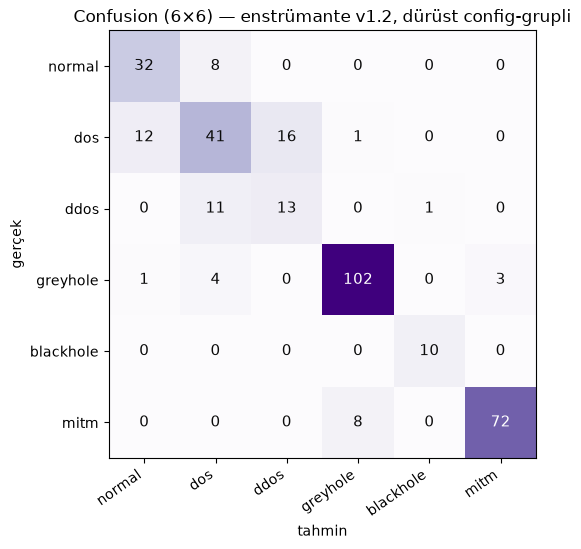

In [5]:
# Confusion (6×6), tag'li OOF — beklenen iki sızıntı: ddos->dos (eşit hacim) ve mitm->greyhole
cm = confusion_matrix(y, oof_tag, labels=CLASSES)
fig, ax = plt.subplots(figsize=(6.2, 5.6)); ax.imshow(cm, cmap="Purples")
ax.set_xticks(range(6), CLASSES, rotation=35, ha="right"); ax.set_yticks(range(6), CLASSES)
ax.set_xlabel("tahmin"); ax.set_ylabel("gerçek")
ax.set_title("Confusion (6×6) — enstrümante v1.2, dürüst config-grupli")
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > cm.max()/2 else "#0b0b0b")
fig.tight_layout(); fig.savefig("figs/P-confusion-instrumented-v1.2.png", dpi=130); plt.show()

**Okuma.** macro-F1 tag ile tag'siz arasında pratikte değişmiyor: damga genel detektörü
**yükseltmiyor**. Yaptığı, zamanlama karışıklığını çözmek — `mitm` F1'i yükseliyor ve confusion
matrisinde beklenen iki sızıntı kalıyor: `ddos → dos` (eşit hacim imzası, Adım 10) ve
`mitm → greyhole` (dizin altındaki tutma, teslim saldırısı gibi okunuyor).

## 4. MITM tespit–şiddet eğrisi ve kat-başı kararlılık

Tespit (atak denme) her `d`'de doygun olmalı — aracının salt varlığı yeterli (Adım 7). Asıl
soru **doğru tipleme**: hangi tutmadan itibaren `mitm` deniyor? d ≥ 20 eğitildiği için OOF,
d < 20 prob (tam-fit modelle). Ayrıca kat-başı MITM F1 yayılımı: tahmin ne kadar kırılgan?

kat-başı MITM F1: [1.0, 0.976, 1.0, 0.909, 0.333]  (MITM içeren kat: 5/5)



     d  n  trained  detect  typed
  1.0 10    False     1.0    0.1
  2.0 10    False     1.0    0.1
  5.0 10    False     1.0    0.1
 10.0 10    False     1.0    0.2
 20.0 10     True     1.0    0.2
 30.0 10     True     1.0    1.0
 40.0 10     True     1.0    1.0
 50.0 10     True     1.0    1.0
 70.0 10     True     1.0    1.0
100.0 10     True     1.0    1.0
150.0 10     True     1.0    1.0
200.0 10     True     1.0    1.0


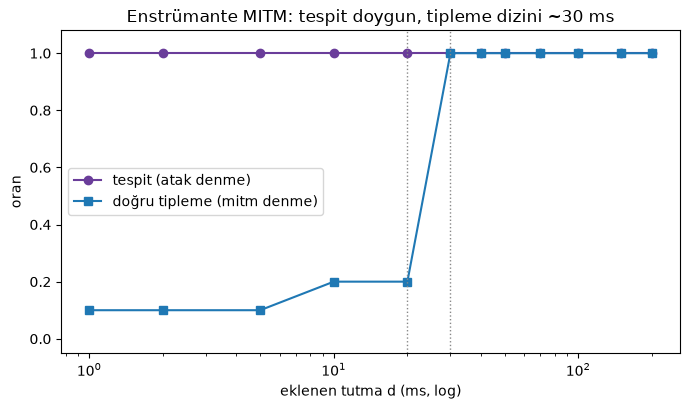

In [6]:
# kat-başı MITM F1 (tipleme kararlılığı)
fold = []
for tri, tei in CV.split(Xtag, y, groups=g):
    m = RandomForestClassifier(**RF).fit(Xtag.iloc[tri], y.iloc[tri]); yy = y.iloc[tei]
    if (yy == "mitm").any():
        p = pd.Series(m.predict(Xtag.iloc[tei]), index=yy.index)
        fold.append(f1_score(yy == "mitm", p == "mitm"))
print("kat-başı MITM F1:", [round(f,3) for f in fold],
      f" (MITM içeren kat: {len(fold)}/5)")

# eğri: d>=20 OOF, d<20 tam-fit prob
fitted = RandomForestClassifier(**RF).fit(Xtag, y)
curve = []
for d in sorted(mitm.intensity.unique()):
    if d >= 20:
        pred = oof_tag[(full.label_class == "mitm") & (full.intensity == d)]
    else:
        pred = pd.Series(fitted.predict(build_X(mitm[mitm.intensity == d], feats=INSTRUMENTED_FEATURES)))
    curve.append(dict(d=float(d), n=int(len(pred)), trained=bool(d >= 20),
                      detect=float((pred != "normal").mean()), typed=float((pred == "mitm").mean())))
cur = pd.DataFrame(curve)
print("\n", cur.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(cur.d, cur.detect, "o-", label="tespit (atak denme)", color="#6a3d9a")
ax.plot(cur.d, cur.typed, "s-", label="doğru tipleme (mitm denme)", color="#1f78b4")
ax.axvline(20, ls=":", color="#888", lw=1); ax.axvline(30, ls=":", color="#888", lw=1)
ax.set_xscale("log"); ax.set_xlabel("eklenen tutma d (ms, log)"); ax.set_ylabel("oran")
ax.set_ylim(-0.05, 1.08); ax.set_title("Enstrümante MITM: tespit doygun, tipleme dizini ~30 ms")
ax.legend(); fig.tight_layout(); fig.savefig("figs/Q-mitm-curve-instrumented-v1.2.png", dpi=130); plt.show()

**Okuma.** Tespit her `d`'de 1.0 (aracının varlığı). Doğru tipleme d ≤ 20 ms'de 0.1–0.2,
**d ≥ 30 ms'de 1.0**: bir zamanlama-MITM, tutması ~30 ms'yi aştığında güvenilir tipleniyor;
altında zararsız/grey aracının izinin içinde kalıp `greyhole` tipleniyor — pasif katmanda
gördüğümüz tez, artık zamanlama ekseninde. Kat-başı yayılımda tek zayıf kat d=20'yi (dizin tam
üstü) tutan kattır; bu daha çok tohumun kaldırmayacağı gerçek bir sınır, örneklem eksikliği değil.

## 5. Yayımlanan v1.2 modeliyle tutarlılık

Yukarıdaki değerlendirme dürüst OOF'tur (kat-başı). Yayımlanan `detector_v1.2_instrumented`
ise tüm eğitim setine fit edilmiş **son** modeldir (v1.1'in freeze mantığı). Notebook'un yeniden
fit ettiği model, yayımlanan modelle **aynı tahminleri** vermeli — yoksa aşağıdaki her sayı
başka bir modeli anlatır.

In [7]:
import joblib
REL = next(p for p in [Path("../day9-20072026-release/release"),
                       Path("my-work/day9-20072026-release/release")] if p.exists())
released = joblib.load(REL / "detector_v1.2_instrumented.joblib")
mine = RandomForestClassifier(**RF).fit(Xtag, y)
same = (released.predict(Xtag) == mine.predict(Xtag)).mean()
print(f"yayımlanan v1.2 ile bu notebook'un modeli aynı tahmin oranı: {same:.4f}")
assert same == 1.0, "yayımlanan model kendi tahminlerini yeniden üretmiyor — şema/veri kaymış"
print("✓ tutarlı — yayımlanan artefakt bu notebook'un ürettiği modeldir")

out = dict(macro_tag=float(mt), macro_free=float(mf), n_runs=len(full),
           per_class={c: {k: rt[c][k] for k in ('precision','recall','f1-score')} for c in CLASSES},
           mitm_fold_f1=[float(x) for x in fold], curve=curve)
Path("11-sixclass-results.json").write_text(json.dumps(out, indent=2))
print("yazıldı: 11-sixclass-results.json")

yayımlanan v1.2 ile bu notebook'un modeli aynı tahmin oranı: 1.0000
✓ tutarlı — yayımlanan artefakt bu notebook'un ürettiği modeldir
yazıldı: 11-sixclass-results.json


## 6. Sonuç — iki katmanlı, açıkça sınırlı

| | tag'siz (pasif) | tag'li (enstrümante) |
|---|---|---|
| macro-F1 | ~0.78 | ~0.78 (değişmiyor) |
| `mitm` F1 | ~0.81 | **~0.93** |
| tipleme dizini | — | d ≥ 30 ms |

Damga **gerçek ama sınırlı** bir katkı: `mitm`'i tiplenebilir kılar ve zararsız-relay'i `mitm`
sanma hatasını ezer, ama (a) genel macro-F1'i yükseltmez, (b) yanlış-alarmı silmez — yalnız
`mitm` sınıfından `greyhole` sınıfına taşır (yol üstü zararsız aracının istemsiz kaybı hafif
grey-hole'den mekanik olarak ayrılamaz), ve (c) pasif değildir (uç cihaz + aracı işbirliği
varsayar). Bu yüzden ana bulguyu **çürütmez, keskinleştirir**: pasif akış ölçümü saldırının
niyetini değil mekaniği okur; körlük ölçümün genel değil **pasif** katmanın özelliğidir.

Bu sonuç kanonik v1.1'in yerine geçmez; ayrı enstrümante varyant v1.2 olarak durur
(rapor §7.4.1, MODEL_CARD §8).